In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
conn = sqlite3.connect("../vendor_analysis.db")

print("database connected successfully")

database connected successfully


In [6]:
query_revenue = """
SELECT 
    VendorNo AS VendorNumber,
    VendorName,
    SUM(SalesDollars) AS TotalSalesRevenue
FROM sales
GROUP BY VendorNo, VendorName
ORDER BY TotalSalesRevenue DESC
LIMIT 10;
"""

df_revenue = pd.read_sql_query(query_revenue, conn)

df_revenue

,VendorNumber,VendorName,TotalSalesRevenue
0,3960,DIAGEO NORTH AMERICA INC,68742416.99
1,4425,MARTIGNETTI COMPANIES,40992395.93
2,17035,PERNOD RICARD USA,32281247.95
3,12546,JIM BEAM BRANDS COMPANY,31906320.54
4,480,BACARDI USA INC,25014556.89
5,1392,CONSTELLATION BRANDS INC,24469172.93
6,3252,E & J GALLO WINERY,18556085.61
7,1128,BROWN-FORMAN CORP,18478557.47
8,9165,ULTRA BEVERAGE COMPANY LLP,17822938.45
9,9552,M S WALKER INC,15465247.75


<function matplotlib.pyplot.show(close=None, block=None)>

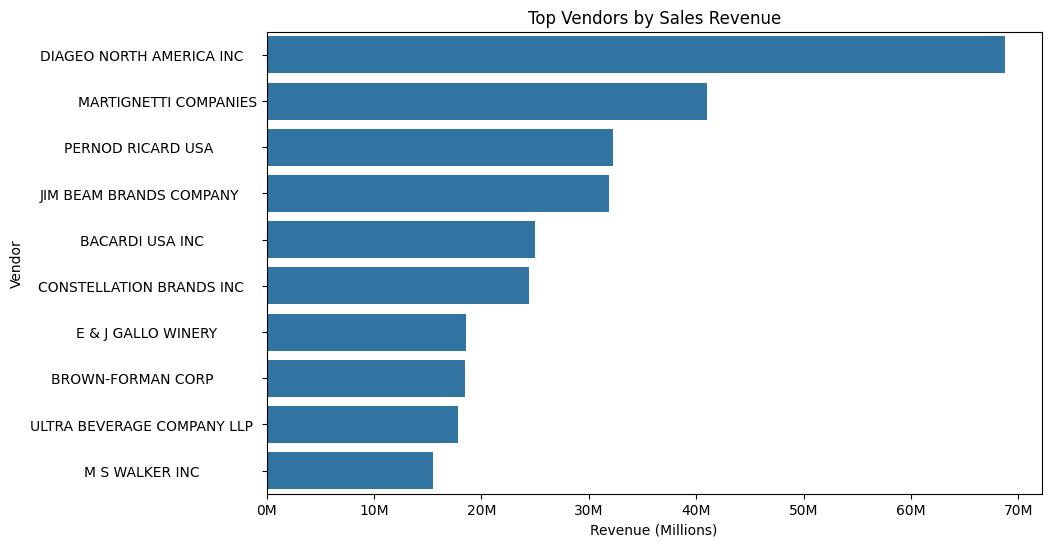

In [7]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df_revenue,
    x="TotalSalesRevenue",
    y="VendorName"
)

plt.title("Top Vendors by Sales Revenue")
plt.xlabel("Revenue (Millions)")
plt.ylabel("Vendor")

plt.gca().xaxis.set_major_formatter(lambda x, _: f'{x/1e6:.0f}M')
plt.show

In [8]:
query_proft = """
WITH purchase_totals AS (
    SELECT
        VendorNumber,
        MIN(VendorName) AS VendorName,
        SUM(Dollars) AS TotalPurchaseSpend
    FROM purchases
    GROUP BY VendorNumber
),

sales_totals AS (
    SELECT
        VendorNo AS VendorNumber,
        MIN(VendorName) AS VendorName,
        SUM(SalesDollars) AS TotalSalesRevenue
    FROM sales
    GROUP BY VendorNo
)

SELECT
    p.VendorNumber,
    p.VendorName,
    p.TotalPurchaseSpend,
    s.TotalSalesRevenue,
    s.TotalSalesRevenue - p.TotalPurchaseSpend AS EstimatedProfit,
    ROUND((s.TotalSalesRevenue - p.TotalPurchaseSpend) / s.TotalSalesRevenue, 3) AS EstimatedProfitMargin
FROM purchase_totals p
JOIN sales_totals s
    ON p.VendorNumber = s.VendorNumber
ORDER BY EstimatedProfit DESC
LIMIT 10;
"""
df_profit = pd.read_sql_query(query_proft, conn)

df_profit

,VendorNumber,VendorName,TotalPurchaseSpend,TotalSalesRevenue,EstimatedProfit,EstimatedProfitMargin
0,3960,DIAGEO NORTH AMERICA INC,50959796.85,68742416.99,17782620.14,0.259
1,4425,MARTIGNETTI COMPANIES,27861690.02,41047306.30,13185616.28,0.321
2,1392,CONSTELLATION BRANDS INC,15573917.90,24469172.93,8895255.03,0.364
3,17035,PERNOD RICARD USA,24124091.56,32281247.95,8157156.39,0.253
4,12546,JIM BEAM BRANDS COMPANY,24203151.05,31906320.54,7703169.49,0.241
5,480,BACARDI USA INC,17624378.72,25014556.89,7390178.17,0.295
6,3252,E & J GALLO WINERY,12289608.09,18556085.61,6266477.52,0.338
7,1128,BROWN-FORMAN CORP,13529433.08,18478557.47,4949124.39,0.268
8,9165,ULTRA BEVERAGE COMPANY LLP,13210613.93,17822938.45,4612324.52,0.259
9,9552,M S WALKER INC,10935817.30,15465247.75,4529430.45,0.293


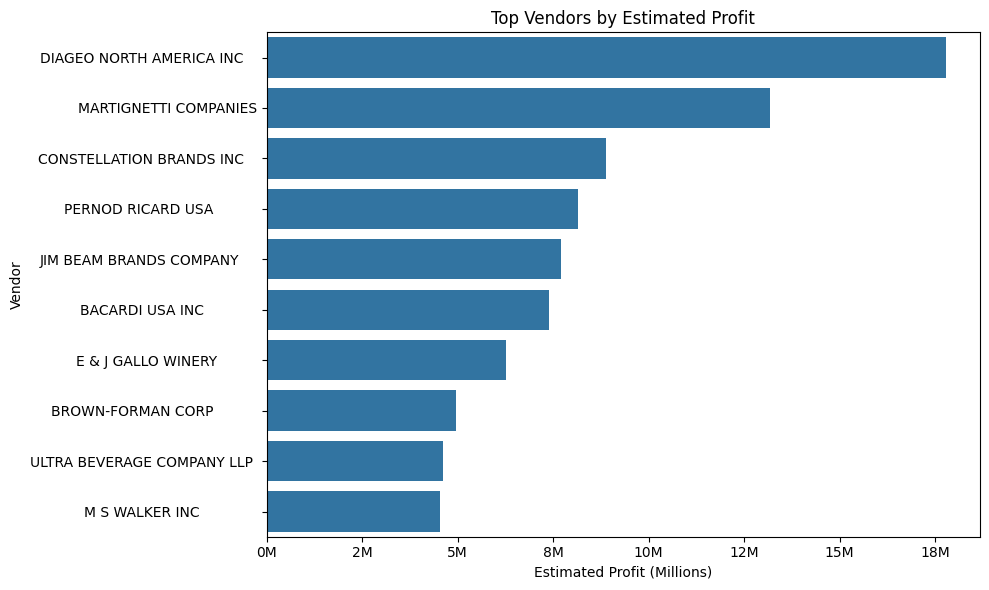

In [9]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df_profit,
    x="EstimatedProfit",
    y="VendorName"
)

plt.title("Top Vendors by Estimated Profit")
plt.xlabel("Estimated Profit (Millions)")
plt.ylabel("Vendor")

plt.gca().xaxis.set_major_formatter(lambda x, _: f'{x/1e6:.0f}M')

plt.tight_layout()
plt.show()

In [10]:
query_ratio = """
WITH purchase_totals AS (
    SELECT 
        VendorNumber,
        MIN(VendorName) AS VendorName,
        SUM(Dollars) AS TotalPurchaseSpend
    FROM purchases
    GROUP BY VendorNumber
),

sales_totals AS (
    SELECT
        VendorNo AS VendorNumber,
        SUM(SalesDollars) AS TotalSalesRevenue
    FROM sales
    GROUP BY VendorNo
)

SELECT
    p.VendorNumber,
    p.VendorName,
    p.TotalPurchaseSpend,
    s.TotalSalesRevenue,
    ROUND(s.TotalSalesRevenue / p.TotalPurchaseSpend, 2) AS SalesToPurchaseRatio
FROM purchase_totals p
JOIN sales_totals s
    ON p.VendorNumber = s.VendorNumber
WHERE p.TotalPurchaseSpend >= 100000
ORDER BY SalesToPurchaseRatio DESC
LIMIT 10;
"""

df_ratio = pd.read_sql_query(query_ratio, conn)

df_ratio

,VendorNumber,VendorName,TotalPurchaseSpend,TotalSalesRevenue,SalesToPurchaseRatio
0,1601,VRANKEN AMERICA,208330.15,341658.31,1.64
1,516,BANFI PRODUCTS CORP,1628866.68,2646325.62,1.62
2,1590,DIAGEO CHATEAU ESTATE WINES,1365472.83,2185030.89,1.60
3,8673,STE MICHELLE WINE ESTATES,3086650.70,4903385.90,1.59
4,9815,WINE GROUP INC,5258636.79,8341165.72,1.59
5,9819,TREASURY WINE ESTATES,2978686.40,4740218.38,1.59
6,1392,CONSTELLATION BRANDS INC,15573917.90,24469172.93,1.57
7,4692,KOBRAND CORPORATION,1808146.33,2840547.87,1.57
8,2000,SOUTHERN GLAZERS W&S OF NE,3740617.38,5769934.33,1.54
9,8892,TRINCHERO FAMILY ESTATES,2252211.31,3467869.81,1.54


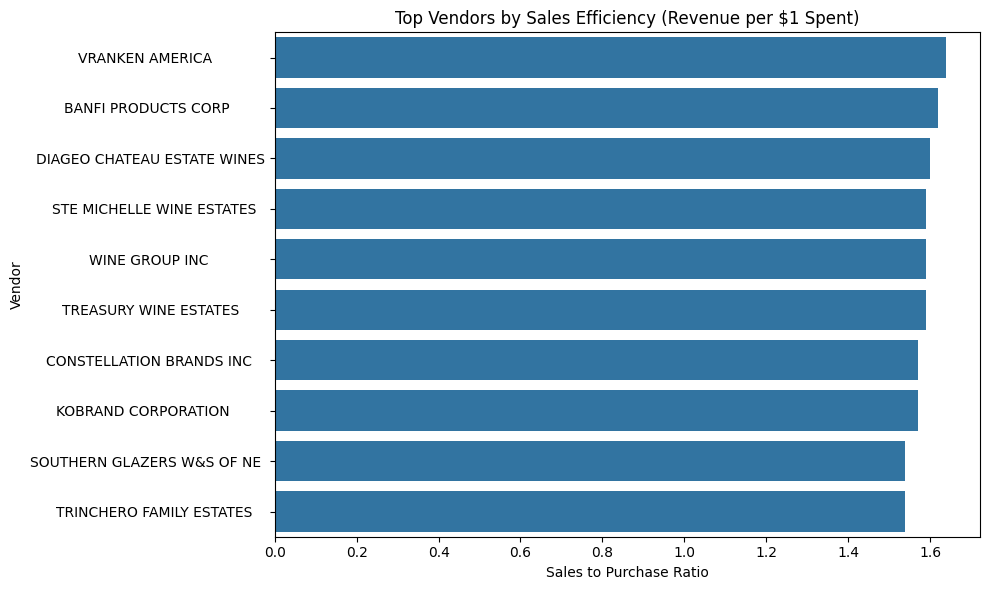

In [11]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df_ratio,
    x="SalesToPurchaseRatio",
    y="VendorName" ) 


plt.title("Top Vendors by Sales Efficiency (Revenue per $1 Spent)")
plt.xlabel("Sales to Purchase Ratio")
plt.ylabel("Vendor")

df_ratio = df_ratio.sort_values(by="SalesToPurchaseRatio", ascending=True)


plt.tight_layout()
plt.show()

In [12]:
query_volume = """
SELECT
    VendorNo AS VendorNumber,
    MIN(VendorName) AS VendorName,
    SUM(SalesQuantity) AS TotalUnitsSold
FROM sales
GROUP BY VendorNo
ORDER BY TotalUnitsSold DESC
LIMIT 10;
"""

df_volume = pd.read_sql_query(query_volume, conn)

df_volume

,VendorNumber,VendorName,TotalUnitsSold
0,3960,DIAGEO NORTH AMERICA INC,5422703
1,12546,JIM BEAM BRANDS COMPANY,2630226
2,4425,MARTIGNETTI COMPANIES,2581318
3,1392,CONSTELLATION BRANDS INC,2301688
4,3252,E & J GALLO WINERY,1809023
5,17035,PERNOD RICARD USA,1613460
6,480,BACARDI USA INC,1457301
7,8004,SAZERAC CO INC,1385046
8,9552,M S WALKER INC,1343481
9,9165,ULTRA BEVERAGE COMPANY LLP,1043235


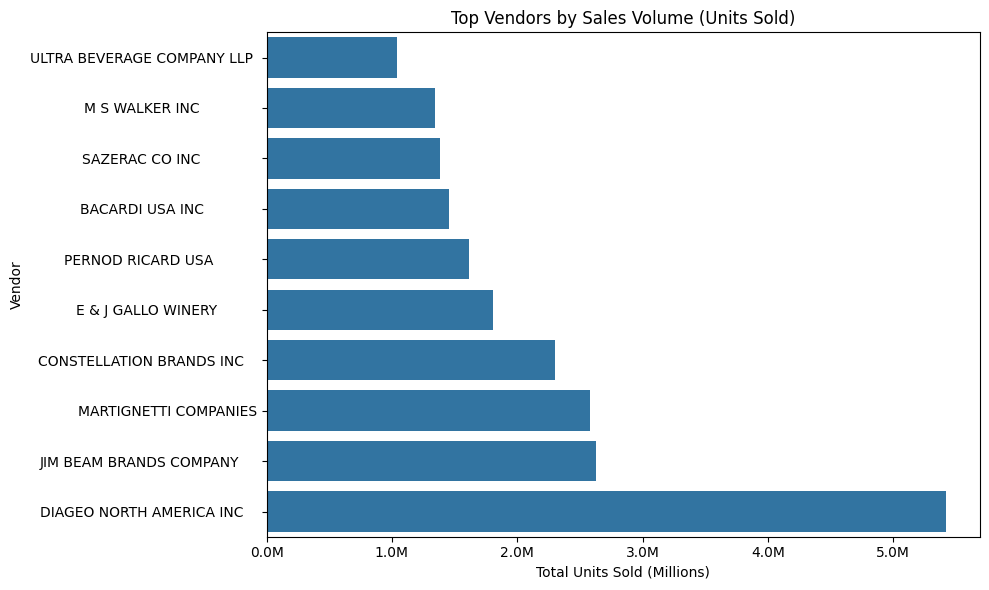

In [13]:
df_volume = df_volume.sort_values(by="TotalUnitsSold", ascending=True)

plt.figure(figsize=(10,6))

sns.barplot(
    data=df_volume,
    x="TotalUnitsSold",
    y="VendorName"
)

plt.title("Top Vendors by Sales Volume (Units Sold)")
plt.xlabel("Total Units Sold (Millions)")
plt.ylabel("Vendor")

plt.gca().xaxis.set_major_formatter(lambda x, _: f'{x/1e6:.1f}M')

plt.tight_layout()
plt.show()
                                    
                                    
        

In [14]:
df_revenue.to_csv("../dashboard/top_vendors_revenue.csv", index=False)

In [15]:
df_profit.to_csv("../dashboard/top_vendors_profit.csv", index=False)

In [17]:
df_ratio.to_csv("../dashboard/top_vendors_efficiency.csv", index=False)

In [16]:
df_volume.to_csv("../dashboard/top_vendors_units.csv", index=False)